# 🧠 Análisis de Salud Mental Estudiantil con Inteligencia Artificial
## Trabajo Final: Aplicación de IA que use librerías de software libre a través de herramientas colaborativas

---
**Descripción:** Análisis de salud mental y contexto socioeconómico de 5 000 estudiantes universitarios mediante técnicas de IA con librerías de software libre.

| Dataset | Origen | Registros | Columnas |
|---|---|---|---|
| `student_mental_health.csv` | CSV | 5 000 | 15 |
| `student_context.db` | SQLite | 5 000 | 18 |
| `student_mental_health_initial.csv` | JOIN (dataset inicial) | 5 000 | 32 |

**ID compartida:** `student_id` (STU0001 – STU5000)

**Librerías:** Pandas · Matplotlib · Bokeh · PygWalker · Scikit-learn · Seaborn

---
## 0. Importación de Librerías

In [1]:
import sqlite3
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool, FactorRange
from bokeh.palettes import Category10_10, Category10_6
from bokeh.layouts import row
from bokeh.io import output_notebook

import pygwalker as pyg

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans

output_notebook()
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

Loading BokehJS ...

---
##  1. Carga de Datos
### 1.1 Dataset CSV: Salud Mental Individual

In [2]:
df_csv = pd.read_csv('data/student_mental_health.csv')
print(f' CSV cargado: {df_csv.shape[0]} filas × {df_csv.shape[1]} columnas')
print(f'   IDs: {df_csv["student_id"].iloc[0]} – {df_csv["student_id"].iloc[-1]}')
print(f'   Nulos: {df_csv.isnull().sum().sum()}')
df_csv.head()

 CSV cargado: 5000 filas × 15 columnas
   IDs: STU0001 – STU5000
   Nulos: 0


,student_id,age,gender,year_of_study,cgpa,depression,anxiety,panic_attack,sought_treatment,sleep_hours,study_hours_per_day,social_media_hours,physical_activity,academic_pressure,family_support
0,STU0001,20,Female,2,4.00,No,Yes,No,No,6,4,4,High,Moderate,Moderate
1,STU0002,20,Male,2,3.40,No,Yes,No,No,8,5,4,High,High,High
2,STU0003,23,Male,1,3.80,No,No,No,No,8,4,4,Moderate,Moderate,High
3,STU0004,19,Male,3,4.00,No,No,No,No,8,4,2,Low,Low,Moderate
4,STU0005,23,Female,2,4.00,No,No,No,No,7,1,8,Moderate,Low,Moderate


In [3]:
print('Información del Dataset CSV:')
df_csv.info()
print('\n Estadísticas descriptivas:')
df_csv.describe()

Información del Dataset CSV:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           5000 non-null   object 
 1   age                  5000 non-null   int64  
 2   gender               5000 non-null   object 
 3   year_of_study        5000 non-null   int64  
 4   cgpa                 5000 non-null   float64
 5   depression           5000 non-null   object 
 6   anxiety              5000 non-null   object 
 7   panic_attack         5000 non-null   object 
 8   sought_treatment     5000 non-null   object 
 9   sleep_hours          5000 non-null   int64  
 10  study_hours_per_day  5000 non-null   int64  
 11  social_media_hours   5000 non-null   int64  
 12  physical_activity    5000 non-null   object 
 13  academic_pressure    5000 non-null   object 
 14  family_support       5000 non-null   object 
dtypes: float6

,age,year_of_study,cgpa,sleep_hours,study_hours_per_day,social_media_hours
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,20.40,2.37,3.75,6.31,4.13,3.98
std,1.80,1.10,0.24,1.16,1.43,1.86
min,18.00,1.00,2.80,3.00,1.00,1.00
25%,19.00,1.00,3.60,6.00,3.00,3.00
50%,20.00,2.00,3.80,6.00,4.00,4.00
75%,22.00,3.00,4.00,7.00,5.00,5.00
max,24.00,4.00,4.00,9.00,9.00,11.00


### 1.2 Dataset SQLite: Contexto Socioeconómico y Universitario

In [4]:
conn   = sqlite3.connect('data/student_context.db')
tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(f' SQLite conectado — Tablas: {tablas["name"].tolist()}')

df_db = pd.read_sql('SELECT * FROM student_context;', conn)
conn.close()

print(f'   Registros: {df_db.shape[0]} filas × {df_db.shape[1]} columnas')
print(f'   IDs: {df_db["student_id"].iloc[0]} – {df_db["student_id"].iloc[-1]}')
print(f'   Nulos: {df_db.isnull().sum().sum()}')
df_db.head()

 SQLite conectado — Tablas: ['student_context']
   Registros: 5000 filas × 18 columnas
   IDs: STU0001 – STU5000
   Nulos: 0


,student_id,universidad,carrera,semestre,modalidad,financiamiento,residencia,nivel_socioeconomico,num_materias,horas_trabajo_semanal,tiempo_desplazamiento,extracurricular_hours,satisfaccion_carrera,calidad_suenio,acceso_internet,participa_actividades,usa_servicios_sm,promedio_previo
0,STU0001,Escuela Politécnica Nacional,Contabilidad,3,Presencial,Recursos propios,Con familia,Bajo,5,0,5,5.50,10.00,3,Excelente,Sí,Sí,10.00
1,STU0002,Pontificia Universidad Católica del Ecuador,Administración de Empresas,1,Semipresencial,Recursos propios,Residencia universitaria,Medio-alto,4,21,29,4.60,7.90,3,Bueno,Sí,No,9.80
2,STU0003,Universidad Técnica del Norte,Ingeniería en Sistemas,6,Presencial,Recursos propios,Solo,Medio-alto,5,14,51,3.60,6.50,3,Excelente,Sí,No,8.20
3,STU0004,Universidad Nacional de Loja,Administración de Empresas,2,Semipresencial,Beca parcial,Arriendo compartido,Alto,7,22,38,3.00,6.20,2,Regular,No,No,6.90
4,STU0005,Universidad Técnica del Norte,Psicología,5,Presencial,Recursos propios,Arriendo compartido,Medio,6,12,33,5.40,8.20,2,Excelente,No,No,10.00


### 1.3 Dataset Inicial: Unión de ambas fuentes (JOIN por student_id)

In [5]:
df = pd.merge(df_csv, df_db, on='student_id', how='inner')
print(f' Dataset inicial (JOIN): {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'   Columnas CSV: {df_csv.shape[1]}  |  Columnas DB: {df_db.shape[1]-1}')
print(f'   IDs coincidentes: {df["student_id"].nunique()}')
print(f'   Nulos: {df.isnull().sum().sum()}')

# Guardar dataset inicial
df.to_csv('data/student_mental_health_initial.csv', index=False)
print('\n Dataset inicial guardado en: data/student_mental_health_initial.csv')
df.head()

 Dataset inicial (JOIN): 5000 filas × 32 columnas
   Columnas CSV: 15  |  Columnas DB: 17
   IDs coincidentes: 5000
   Nulos: 0

 Dataset inicial guardado en: data/student_mental_health_initial.csv


,student_id,age,gender,year_of_study,cgpa,depression,anxiety,panic_attack,sought_treatment,sleep_hours,study_hours_per_day,social_media_hours,physical_activity,academic_pressure,family_support,universidad,carrera,semestre,modalidad,financiamiento,residencia,nivel_socioeconomico,num_materias,horas_trabajo_semanal,tiempo_desplazamiento,extracurricular_hours,satisfaccion_carrera,calidad_suenio,acceso_internet,participa_actividades,usa_servicios_sm,promedio_previo
0,STU0001,20,Female,2,4.00,No,Yes,No,No,6,4,4,High,Moderate,Moderate,Escuela Politécnica Nacional,Contabilidad,3,Presencial,Recursos propios,Con familia,Bajo,5,0,5,5.50,10.00,3,Excelente,Sí,Sí,10.00
1,STU0002,20,Male,2,3.40,No,Yes,No,No,8,5,4,High,High,High,Pontificia Universidad Católica del Ecuador,Administración de Empresas,1,Semipresencial,Recursos propios,Residencia universitaria,Medio-alto,4,21,29,4.60,7.90,3,Bueno,Sí,No,9.80
2,STU0003,23,Male,1,3.80,No,No,No,No,8,4,4,Moderate,Moderate,High,Universidad Técnica del Norte,Ingeniería en Sistemas,6,Presencial,Recursos propios,Solo,Medio-alto,5,14,51,3.60,6.50,3,Excelente,Sí,No,8.20
3,STU0004,19,Male,3,4.00,No,No,No,No,8,4,2,Low,Low,Moderate,Universidad Nacional de Loja,Administración de Empresas,2,Semipresencial,Beca parcial,Arriendo compartido,Alto,7,22,38,3.00,6.20,2,Regular,No,No,6.90
4,STU0005,23,Female,2,4.00,No,No,No,No,7,1,8,Moderate,Low,Moderate,Universidad Técnica del Norte,Psicología,5,Presencial,Recursos propios,Arriendo compartido,Medio,6,12,33,5.40,8.20,2,Excelente,No,No,10.00


---
##  2. Preprocesamiento

In [6]:
# Codificación binaria Yes/No → 1/0
binary_cols = ['depression','anxiety','panic_attack','sought_treatment']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0})

# Codificación ordinal
ord_map = {'Low':0,'Moderate':1,'High':2}
df['physical_activity_num']  = df['physical_activity'].map(ord_map)
df['academic_pressure_num']  = df['academic_pressure'].map(ord_map)
df['family_support_num']     = df['family_support'].map(ord_map)
df['gender_num']             = df['gender'].map({'Female':0,'Male':1})
df['modalidad_num']          = df['modalidad'].map({'Virtual':0,'Semipresencial':1,'Presencial':2})
df['acceso_internet_num']    = df['acceso_internet'].map({'Malo':0,'Regular':1,'Bueno':2,'Excelente':3})
df['nivel_socio_num']        = df['nivel_socioeconomico'].map(
    {'Bajo':0,'Medio-bajo':1,'Medio':2,'Medio-alto':3,'Alto':4})
df['participa_num']          = df['participa_actividades'].map({'No':0,'Sí':1})
df['usa_sm_num']             = df['usa_servicios_sm'].map({'No':0,'Sí':1})

# Índice de bienestar (ampliado con variables del SQLite)
df['wellbeing_index'] = (
    df['sleep_hours']           * 0.20 +
    df['physical_activity_num'] * 0.15 +
    df['family_support_num']    * 0.15 +
    df['satisfaccion_carrera']  * 0.10 +
    df['extracurricular_hours'] * 0.05 +
    df['calidad_suenio']        * 0.10 -
    df['depression']            * 0.10 -
    df['anxiety']               * 0.10 -
    df['horas_trabajo_semanal'] * 0.02 -
    df['tiempo_desplazamiento'] * 0.003
).round(2)

# Variable objetivo
df['mental_health_issue'] = ((df['depression']==1)|(df['anxiety']==1)).astype(int)
df['mental_status']       = df['mental_health_issue'].map({0:'Sin Problema',1:'Con Problema'})

print(' Preprocesamiento completado')
print(f'   Nuevas columnas: {[c for c in df.columns if c not in df_csv.columns.tolist()+df_db.columns.tolist()]}')
print(f'   Con problema de salud mental: {df["mental_health_issue"].mean()*100:.1f}%')
print(f'   Bienestar (Wellbeing) index media: {df["wellbeing_index"].mean():.2f}')
df[['student_id','cgpa','depression','anxiety','wellbeing_index','mental_health_issue','carrera']].head()

 Preprocesamiento completado
   Nuevas columnas: ['physical_activity_num', 'academic_pressure_num', 'family_support_num', 'gender_num', 'modalidad_num', 'acceso_internet_num', 'nivel_socio_num', 'participa_num', 'usa_sm_num', 'wellbeing_index', 'mental_health_issue', 'mental_status']
   Con problema de salud mental: 42.8%
   Bienestar (Wellbeing) index media: 2.46


,student_id,cgpa,depression,anxiety,wellbeing_index,mental_health_issue,carrera
0,STU0001,4.00,0,1,3.11,1,Contabilidad
1,STU0002,3.40,0,1,2.91,1,Administración de Empresas
2,STU0003,3.80,0,0,2.75,0,Ingeniería en Sistemas
3,STU0004,4.00,0,0,2.17,0,Administración de Empresas
4,STU0005,4.00,0,0,2.65,0,Psicología


---
##  3. Visualizaciones con Matplotlib
### 3.1 Distribución General del Dataset

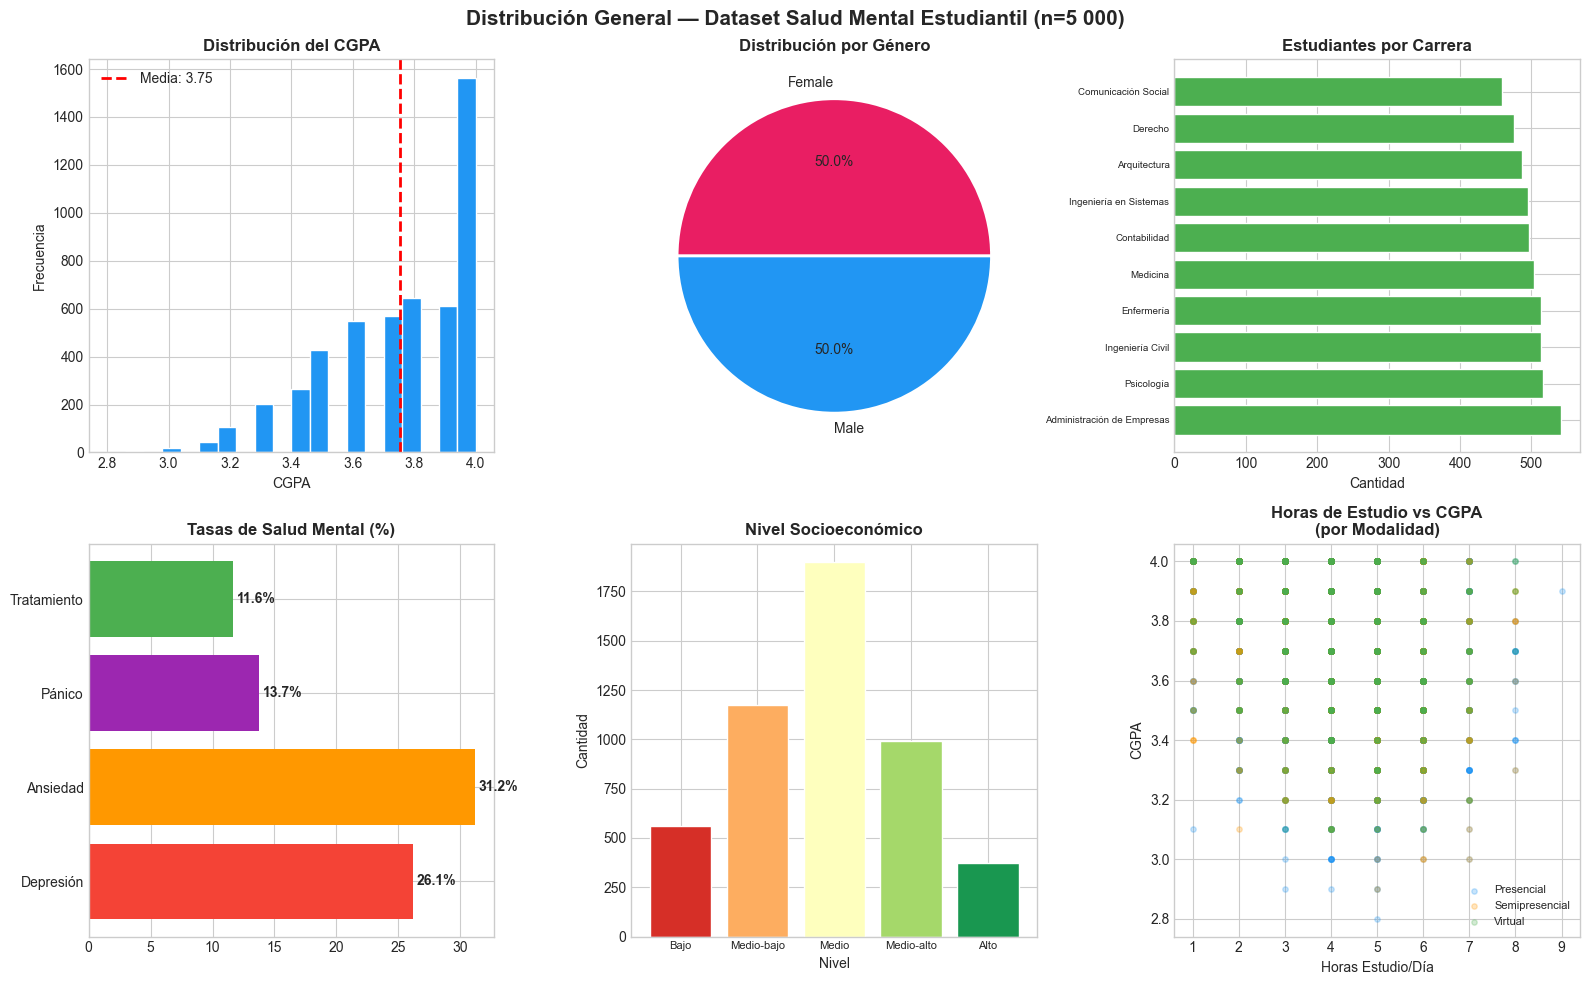

 Figura 1 guardada en: data/viz_01_distribucion.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución General — Dataset Salud Mental Estudiantil (n=5 000)',
             fontsize=15, fontweight='bold')
colors = ['#2196F3','#E91E63','#4CAF50','#FF9800','#9C27B0','#00BCD4']

# 1. CGPA
axes[0,0].hist(df['cgpa'], bins=20, color=colors[0], edgecolor='white')
axes[0,0].axvline(df['cgpa'].mean(), color='red', ls='--', lw=2,
                   label=f'Media: {df["cgpa"].mean():.2f}')
axes[0,0].set_title('Distribución del CGPA', fontweight='bold')
axes[0,0].set_xlabel('CGPA'); axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend()

# 2. Género
gc = df['gender'].value_counts()
axes[0,1].pie(gc, labels=gc.index, autopct='%1.1f%%',
              colors=['#E91E63','#2196F3'],
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,1].set_title('Distribución por Género', fontweight='bold')

# 3. Carrera universitaria
cc = df['carrera'].value_counts()
axes[0,2].barh(cc.index, cc.values, color=colors[2], edgecolor='white')
axes[0,2].set_title('Estudiantes por Carrera', fontweight='bold')
axes[0,2].set_xlabel('Cantidad')
axes[0,2].tick_params(axis='y', labelsize=7)

# 4. Tasas de salud mental
issues = ['Depresión','Ansiedad','Pánico','Tratamiento']
rates  = [df['depression'].mean()*100, df['anxiety'].mean()*100,
           df['panic_attack'].mean()*100, df['sought_treatment'].mean()*100]
b = axes[1,0].barh(issues, rates, color=['#F44336','#FF9800','#9C27B0','#4CAF50'])
axes[1,0].set_title('Tasas de Salud Mental (%)', fontweight='bold')
for bar, v in zip(b, rates):
    axes[1,0].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                   f'{v:.1f}%', va='center', fontweight='bold')

# 5. Distribución nivel socioeconómico
sc = df['nivel_socioeconomico'].value_counts().reindex(
    ['Bajo','Medio-bajo','Medio','Medio-alto','Alto'])
c_sc = plt.cm.RdYlGn(np.linspace(0.1, 0.9, 5))
axes[1,1].bar(sc.index, sc.values, color=c_sc, edgecolor='white')
axes[1,1].set_title('Nivel Socioeconómico', fontweight='bold')
axes[1,1].set_xlabel('Nivel'); axes[1,1].set_ylabel('Cantidad')
axes[1,1].tick_params(axis='x', labelsize=8)

# 6. Modalidad de estudio vs CGPA
for mod, col in zip(['Presencial','Semipresencial','Virtual'],
                     ['#2196F3','#FF9800','#4CAF50']):
    s = df[df['modalidad']==mod]
    axes[1,2].scatter(s['study_hours_per_day'], s['cgpa'],
                      alpha=0.25, c=col, label=mod, s=15)
axes[1,2].set_title('Horas de Estudio vs CGPA\n(por Modalidad)', fontweight='bold')
axes[1,2].set_xlabel('Horas Estudio/Día'); axes[1,2].set_ylabel('CGPA')
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('data/viz_01_distribucion.png', dpi=130, bbox_inches='tight')
plt.show()
print(' Figura 1 guardada en: data/viz_01_distribucion.png')

### 3.2 Correlaciones y Variables Clave

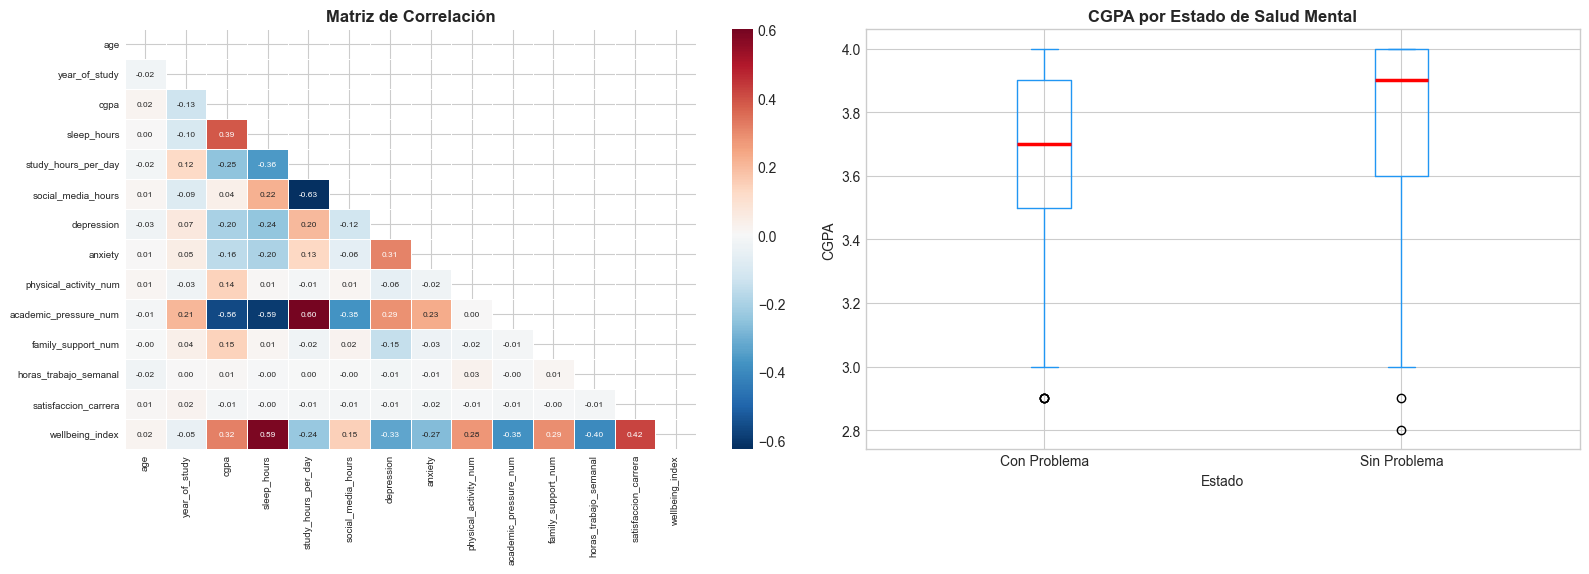

 Figura 2 guardada en: data/viz_02_correlacion.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mapa de Correlación y CGPA por Salud Mental', fontsize=14, fontweight='bold')

num_cols = ['age','year_of_study','cgpa','sleep_hours','study_hours_per_day',
            'social_media_hours','depression','anxiety','physical_activity_num',
            'academic_pressure_num','family_support_num','horas_trabajo_semanal',
            'satisfaccion_carrera','wellbeing_index']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], linewidths=0.4, annot_kws={'size':6})
axes[0].set_title('Matriz de Correlación', fontweight='bold')
axes[0].tick_params(labelsize=7)

df.boxplot(column='cgpa', by='mental_status', ax=axes[1],
           boxprops=dict(color='#2196F3'),
           medianprops=dict(color='red', linewidth=2.5),
           whiskerprops=dict(color='#2196F3'),
           capprops=dict(color='#2196F3'))
axes[1].set_title('CGPA por Estado de Salud Mental', fontweight='bold')
axes[1].set_xlabel('Estado'); axes[1].set_ylabel('CGPA')
plt.suptitle('')

plt.tight_layout()
plt.savefig('data/viz_02_correlacion.png', dpi=130, bbox_inches='tight')
plt.show()
print(' Figura 2 guardada en: data/viz_02_correlacion.png')

### 3.3 Análisis por Carrera y Contexto Socioeconómico

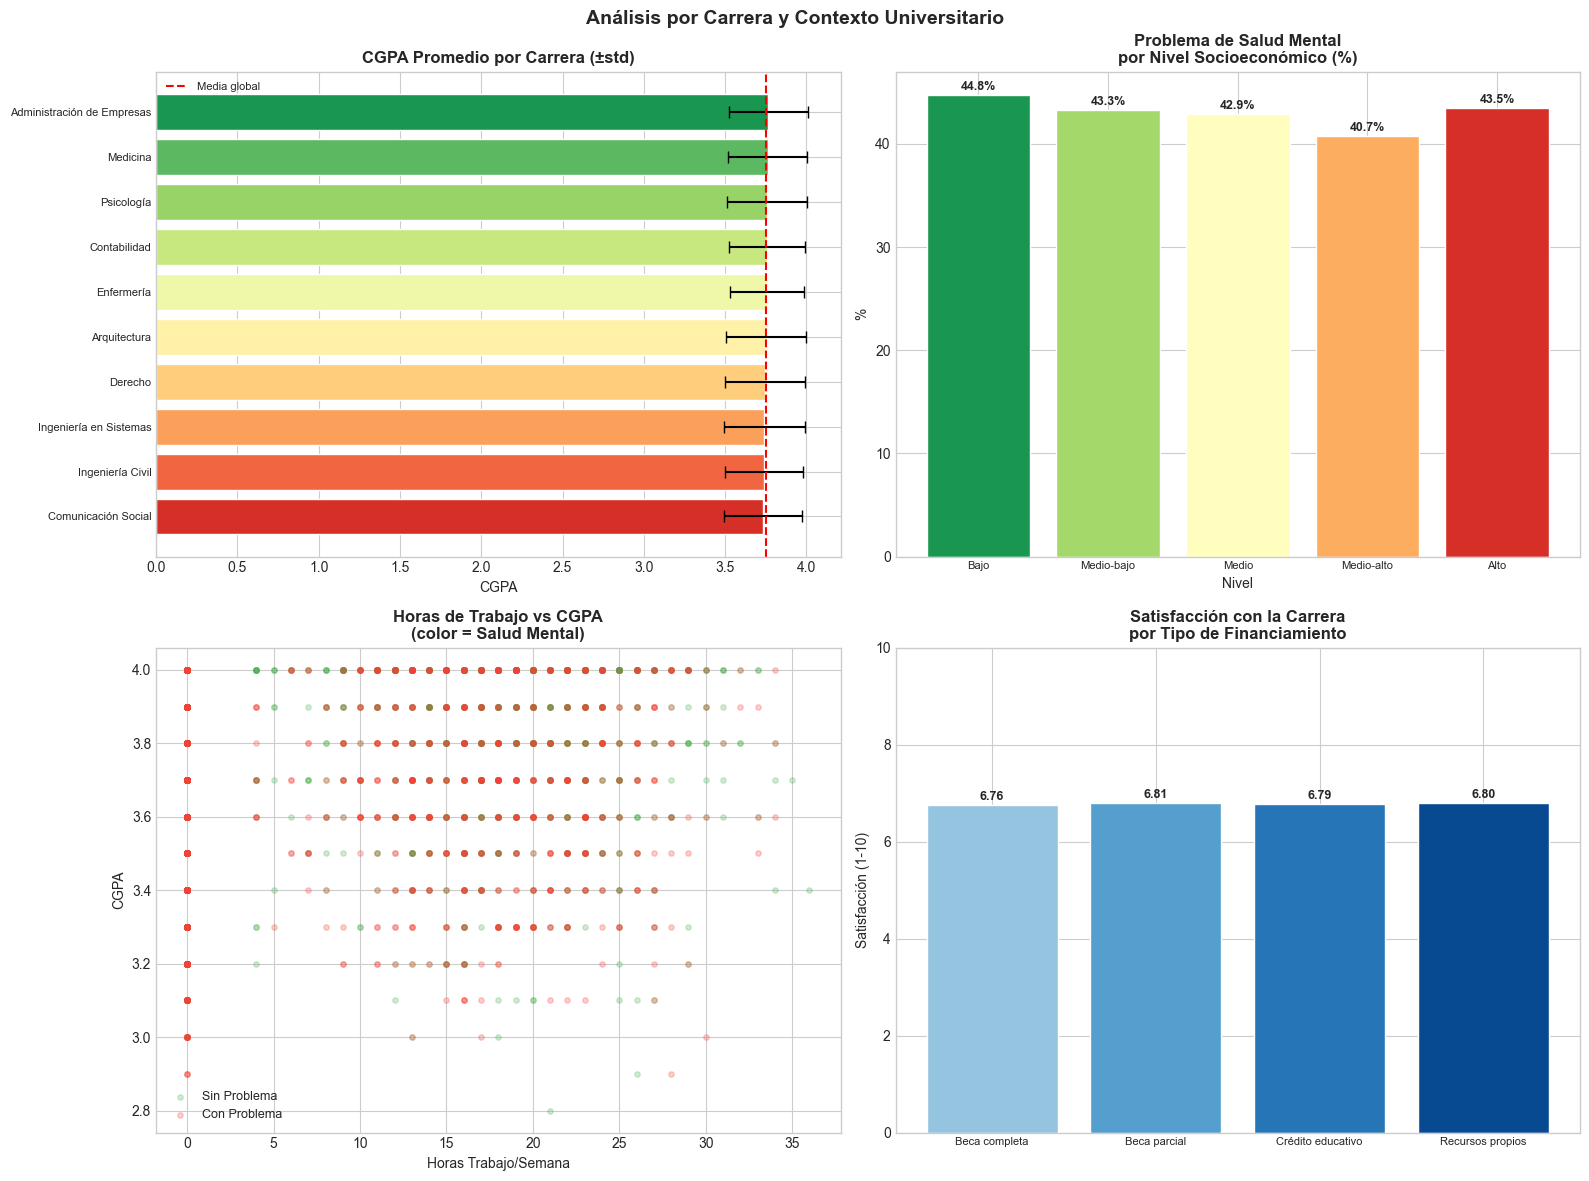

 Figura 3 guardada en: data/viz_03_carrera_contexto.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis por Carrera y Contexto Universitario', fontsize=14, fontweight='bold')

# 1. CGPA promedio por carrera (barras + error)
cgpa_car = df.groupby('carrera')['cgpa'].agg(['mean','std']).sort_values('mean')
c_b = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(cgpa_car)))
axes[0,0].barh(cgpa_car.index, cgpa_car['mean'], xerr=cgpa_car['std'],
               color=c_b, edgecolor='white', capsize=4)
axes[0,0].set_title('CGPA Promedio por Carrera (±std)', fontweight='bold')
axes[0,0].set_xlabel('CGPA'); axes[0,0].tick_params(axis='y', labelsize=8)
axes[0,0].axvline(df['cgpa'].mean(), color='red', ls='--', lw=1.5, label='Media global')
axes[0,0].legend(fontsize=8)

# 2. Tasa de problema mental por nivel socioeconómico
niveles_ord = ['Bajo','Medio-bajo','Medio','Medio-alto','Alto']
sm_nivel = df.groupby('nivel_socioeconomico')['mental_health_issue'].mean()*100
sm_nivel = sm_nivel.reindex(niveles_ord)
c_n = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 5))
bars = axes[0,1].bar(sm_nivel.index, sm_nivel.values, color=c_n, edgecolor='white')
axes[0,1].set_title('Problema de Salud Mental\npor Nivel Socioeconómico (%)', fontweight='bold')
axes[0,1].set_xlabel('Nivel'); axes[0,1].set_ylabel('%')
for bar, v in zip(bars, sm_nivel.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0,1].tick_params(axis='x', labelsize=8)

# 3. Horas trabajo vs CGPA (color = salud mental)
for estado, col in [('Sin Problema','#4CAF50'),('Con Problema','#F44336')]:
    s = df[df['mental_status']==estado]
    axes[1,0].scatter(s['horas_trabajo_semanal'], s['cgpa'],
                      alpha=0.25, c=col, label=estado, s=15)
axes[1,0].set_title('Horas de Trabajo vs CGPA\n(color = Salud Mental)', fontweight='bold')
axes[1,0].set_xlabel('Horas Trabajo/Semana'); axes[1,0].set_ylabel('CGPA')
axes[1,0].legend(fontsize=9)

# 4. Satisfacción con carrera por financiamiento
fin_order = ['Beca completa','Beca parcial','Crédito educativo','Recursos propios']
sat_fin = df.groupby('financiamiento')['satisfaccion_carrera'].mean().reindex(fin_order)
c_f = plt.cm.Blues(np.linspace(0.4, 0.9, 4))
b4 = axes[1,1].bar(sat_fin.index, sat_fin.values, color=c_f, edgecolor='white')
axes[1,1].set_title('Satisfacción con la Carrera\npor Tipo de Financiamiento', fontweight='bold')
axes[1,1].set_ylabel('Satisfacción (1-10)')
axes[1,1].set_ylim(0, 10)
for b, v in zip(b4, sat_fin.values):
    axes[1,1].text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
                   f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[1,1].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('data/viz_03_carrera_contexto.png', dpi=130, bbox_inches='tight')
plt.show()
print(' Figura 3 guardada en: data/viz_03_carrera_contexto.png')

---
##  4. Visualizaciones con Bokeh (Interactivas)
### 4.1 Scatter Interactivo: CGPA vs Bienestar

In [10]:
p1 = figure(title='CGPA vs Índice de Bienestar (por Estado de Salud Mental)',
            x_axis_label='Índice de Bienestar', y_axis_label='CGPA',
            width=720, height=450,
            tools='pan,wheel_zoom,box_zoom,reset,hover,save')

for estado, color in [('Sin Problema','#4CAF50'),('Con Problema','#F44336')]:
    s = df[df['mental_status']==estado].copy()
    src = ColumnDataSource(s)
    p1.circle('wellbeing_index','cgpa', source=src, size=8, alpha=0.55,
               color=color, legend_label=estado,
               line_color='white', line_width=0.4)

p1.select(HoverTool).tooltips = [
    ('ID','@student_id'),('Carrera','@carrera'),
    ('CGPA','@cgpa{0.2f}'),('Bienestar','@wellbeing_index{0.2f}'),
    ('Sueño','@sleep_hours h'),('Trabajo','@horas_trabajo_semanal h/sem'),
    ('Universidad','@universidad'),('Estado','@mental_status')
]
p1.legend.location = 'top_left'
p1.legend.click_policy = 'hide'
p1.title.text_font_size = '13px'
show(p1)
print(' Bokeh scatter interactivo generado')

 Bokeh scatter interactivo generado


### 4.2 Barras Interactivas: Salud Mental por Carrera

In [11]:
sm_car = df.groupby('carrera')[['depression','anxiety','sought_treatment']].mean()*100
sm_car = sm_car.reset_index()
sm_car.columns = ['carrera','depresion','ansiedad','busca_ayuda']
categorias = ['Depresión','Ansiedad','Busca Ayuda']
carreras_bk = sm_car['carrera'].tolist()
x_range = [(c, cat) for c in carreras_bk for cat in categorias]
values  = []
for _, r in sm_car.iterrows():
    values.extend([r['depresion'], r['ansiedad'], r['busca_ayuda']])

src2 = ColumnDataSource(dict(
    x=x_range, values=values,
    colors=['#F44336','#FF9800','#4CAF50']*len(carreras_bk)
))
p2 = figure(x_range=FactorRange(*x_range),
            title='Tasas de Salud Mental por Carrera (%)',
            width=900, height=450,
            tools='pan,wheel_zoom,reset,hover,save')
p2.vbar(x='x', top='values', width=0.85, source=src2, color='colors', alpha=0.85)
p2.select(HoverTool).tooltips = [('Carrera/Indicador','@x'),('Porcentaje','@values{0.1f}%')]
p2.xaxis.major_label_orientation = 1.3
p2.xgrid.grid_line_color = None
p2.title.text_font_size = '13px'
show(p2)
print(' Bokeh barras agrupadas interactivas generadas')

 Bokeh barras agrupadas interactivas generadas


### 4.3 Líneas Interactivas: CGPA por Universidad

In [12]:
cgpa_univ = df.groupby(['universidad','year_of_study'])['cgpa'].mean().reset_index()
universidades = cgpa_univ['universidad'].unique()

p3 = figure(title='Evolución del CGPA por Año de Estudio y Universidad',
            x_axis_label='Año de Estudio', y_axis_label='CGPA Promedio',
            width=800, height=450,
            tools='pan,wheel_zoom,reset,hover,save')

for univ, color in zip(universidades, Category10_10):
    s = cgpa_univ[cgpa_univ['universidad']==univ].sort_values('year_of_study')
    src3 = ColumnDataSource(s)
    short = univ.split()[-1]  # última palabra del nombre
    p3.line('year_of_study','cgpa', source=src3, line_width=2,
             color=color, alpha=0.9, legend_label=short)
    p3.circle('year_of_study','cgpa', source=src3, size=8, color=color)

p3.select(HoverTool).tooltips = [
    ('Universidad','@universidad'),
    ('Año','@year_of_study'),
    ('CGPA','@cgpa{0.2f}')
]
p3.legend.location = 'bottom_right'
p3.legend.click_policy = 'hide'
p3.legend.label_text_font_size = '8px'
p3.xaxis.ticker = [1,2,3,4]
p3.title.text_font_size = '13px'
show(p3)
print(' Bokeh líneas interactivas generadas (click en leyenda para filtrar)')

 Bokeh líneas interactivas generadas (click en leyenda para filtrar)


---
##  5. Exploración Interactiva con PygWalker
### 5.1 Dataset Inicial Completo (CSV + SQLite)

In [13]:
print(' PygWalker — Dataset Inicial (5 000 × 32 columnas)')
print('   Sugerencias: X=cgpa | Y=wellbeing_index | Color=mental_status')
print('   O: X=carrera | Y=depression | Tipo=Barras')
df_pyg = df.copy()
int_cols = df_pyg.select_dtypes(include=['int64','int32']).columns.tolist()
df_pyg[int_cols] = df_pyg[int_cols].astype('float64')
pyg.walk(df_pyg)

 PygWalker — Dataset Inicial (5 000 × 32 columnas)
   Sugerencias: X=cgpa | Y=wellbeing_index | Color=mental_status
   O: X=carrera | Y=depression | Tipo=Barras


Box(children=(HTML(value='\n<div id="ifr-pyg-000652940743593dxp4IPGjC0YbSrRok" style="height: auto">\n    <hea…

### 5.2 Análisis por Universidad y Carrera

In [14]:
print(' PygWalker: Resumen por Universidad y Carrera')
print('   Sugerencias: X=universidad | Y=cgpa | Color=nivel_socioeconomico')
agg_univ = df.groupby(['universidad','carrera']).agg(
    cgpa_mean=('cgpa','mean'),
    dep_rate=('depression','mean'),
    anx_rate=('anxiety','mean'),
    bienestar=('wellbeing_index','mean'),
    n_estudiantes=('student_id','count')
).reset_index().round(3)
df_pyg2 = agg_univ.copy()
int_cols2 = df_pyg2.select_dtypes(include=['int64','int32']).columns.tolist()
df_pyg2[int_cols2] = df_pyg2[int_cols2].astype('float64')
pyg.walk(df_pyg2)

 PygWalker: Resumen por Universidad y Carrera
   Sugerencias: X=universidad | Y=cgpa | Color=nivel_socioeconomico


Box(children=(HTML(value='\n<div id="ifr-pyg-00065294074d39e1epSs1kuJK3ig8Pja" style="height: auto">\n    <hea…

---
## 6. Modelos de Inteligencia Artificial 🤖
### 6.1 Clasificación: Predicción de Problema de Salud Mental

In [15]:
features = ['age','year_of_study','cgpa','sleep_hours','study_hours_per_day',
            'social_media_hours','physical_activity_num','academic_pressure_num',
            'family_support_num','gender_num','horas_trabajo_semanal',
            'tiempo_desplazamiento','satisfaccion_carrera','calidad_suenio',
            'extracurricular_hours','nivel_socio_num','participa_num',
            'modalidad_num','acceso_internet_num','promedio_previo']
target = 'mental_health_issue'

X = df[features].copy()
y = df[target].copy()

X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
Xtr_sc = scaler.fit_transform(X_train)
Xte_sc = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=150, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
yp_rf = rf.predict(X_test)

lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=500)
lr.fit(Xtr_sc, y_train)
yp_lr = lr.predict(Xte_sc)

print(' RESULTADOS DE CLASIFICACIÓN')
print('-'*55)
print(f'Random Forest     — Accuracy: {accuracy_score(y_test,yp_rf):.3f}')
print(f'Reg. Logística    — Accuracy: {accuracy_score(y_test,yp_lr):.3f}')
print(f'\nFeatures utilizadas: {len(features)}')
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print('\n Reporte detallado (Random Forest):')
print(classification_report(y_test,yp_rf,
      target_names=['Sin Problema','Con Problema']))

 RESULTADOS DE CLASIFICACIÓN
-------------------------------------------------------
Random Forest     — Accuracy: 0.666
Reg. Logística    — Accuracy: 0.661

Features utilizadas: 20
Train: 3750 | Test: 1250

 Reporte detallado (Random Forest):
              precision    recall  f1-score   support

Sin Problema       0.68      0.77      0.72       715
Con Problema       0.63      0.53      0.57       535

    accuracy                           0.67      1250
   macro avg       0.66      0.65      0.65      1250
weighted avg       0.66      0.67      0.66      1250



In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Resultados de Modelos de IA', fontsize=14, fontweight='bold')

imp = pd.Series(rf.feature_importances_, index=features).sort_values()
c_imp = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(imp)))
imp.plot(kind='barh', ax=axes[0], color=c_imp, edgecolor='white')
axes[0].set_title('Importancia de Variables\n(Random Forest)', fontweight='bold')
axes[0].set_xlabel('Importancia')
axes[0].tick_params(labelsize=8)

for ax, cm_data, title, cmap in zip(
    axes[1:],
    [confusion_matrix(y_test,yp_rf), confusion_matrix(y_test,yp_lr)],
    [f'Random Forest\nAcc={accuracy_score(y_test,yp_rf):.2%}',
     f'Reg. Logística\nAcc={accuracy_score(y_test,yp_lr):.2%}'],
    ['Blues','Oranges']
):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Sin Prob.','Con Prob.'],
                yticklabels=['Sin Prob.','Con Prob.'])
    ax.set_title(f'Confusión — {title}', fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig('data/viz_04_modelos.png', dpi=130, bbox_inches='tight')
plt.show()
print(' Figura 4 guardada en: data/viz_04_modelos.png')

 Figura 4 guardada en: data/viz_04_modelos.png


### 6.2 Clustering K-Means: Perfiles Estudiantiles

👥 Perfiles Estudiantiles (K-Means, k=4):
          cgpa  sleep_hours  study_hours_per_day  social_media_hours  wellbeing_index  satisfaccion_carrera  horas_trabajo_semanal  mental_health_issue
Perfil 1  3.74         6.08                 4.37                3.70             2.08                  6.56                  20.30                 0.46
Perfil 2  3.87         7.16                 2.70                5.70             2.73                  6.77                   3.28                 0.29
Perfil 3  3.84         6.55                 4.82                2.80             2.76                  7.76                   1.28                 0.35
Perfil 4  3.55         5.32                 4.84                3.46             2.17                  6.07                   1.29                 0.62


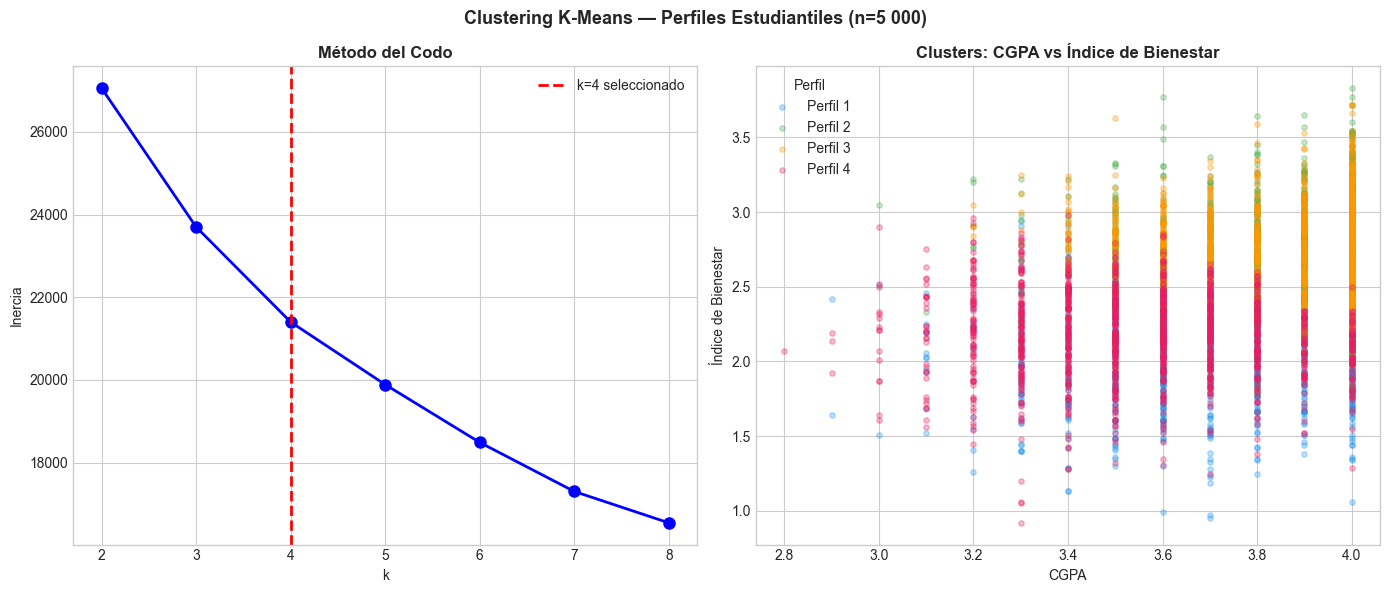

 Figura 5 guardada en: data/viz_05_clustering.png


In [17]:
cluster_features = ['cgpa','sleep_hours','study_hours_per_day',
                    'social_media_hours','wellbeing_index',
                    'satisfaccion_carrera','horas_trabajo_semanal']
Xc = scaler.fit_transform(df[cluster_features])

inertias = [KMeans(n_clusters=k,random_state=42,n_init=10).fit(Xc).inertia_
            for k in range(2,9)]

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(Xc)

desc = df.groupby('cluster')[cluster_features+['mental_health_issue']].mean().round(2)
desc.index = [f'Perfil {i+1}' for i in desc.index]
print('👥 Perfiles Estudiantiles (K-Means, k=4):')
print(desc.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Clustering K-Means — Perfiles Estudiantiles (n=5 000)',
             fontsize=13, fontweight='bold')

axes[0].plot(range(2,9), inertias, 'bo-', lw=2, markersize=8)
axes[0].axvline(4, color='red', ls='--', lw=2, label='k=4 seleccionado')
axes[0].set_title('Método del Codo', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[0].legend()

c_cluster = ['#2196F3','#4CAF50','#FF9800','#E91E63']
for i, (col, lbl) in enumerate(zip(c_cluster, desc.index)):
    m = df['cluster']==i
    axes[1].scatter(df[m]['cgpa'], df[m]['wellbeing_index'],
                    c=col, label=lbl, alpha=0.3, s=15)
axes[1].set_title('Clusters: CGPA vs Índice de Bienestar', fontweight='bold')
axes[1].set_xlabel('CGPA'); axes[1].set_ylabel('Índice de Bienestar')
axes[1].legend(title='Perfil')

plt.tight_layout()
plt.savefig('data/viz_05_clustering.png', dpi=130, bbox_inches='tight')
plt.show()
print(' Figura 5 guardada en: data/viz_05_clustering.png')

---
## 7. Exportar Dataset Final

In [18]:
# Seleccionar columnas finales
cols_originales = list(df_csv.columns) + [c for c in df_db.columns if c != 'student_id']
cols_nuevas     = ['physical_activity_num','academic_pressure_num','family_support_num',
                   'gender_num','modalidad_num','acceso_internet_num','nivel_socio_num',
                   'participa_num','usa_sm_num','wellbeing_index',
                   'mental_health_issue','mental_status','cluster']
df_final = df[cols_originales + cols_nuevas].copy()
df_final.to_csv('data/student_mental_health_final.csv', index=False, encoding='utf-8')

print('💾 Dataset final exportado en: data/student_mental_health_final.csv')
print(f'   Registros: {len(df_final)}')
print(f'   Columnas:  {df_final.shape[1]}')
print(f'   Columnas originales (CSV+DB): {len(cols_originales)}')
print(f'   Columnas derivadas:           {len(cols_nuevas)}')
df_final.head()

💾 Dataset final exportado en: data/student_mental_health_final.csv
   Registros: 5000
   Columnas:  45
   Columnas originales (CSV+DB): 32
   Columnas derivadas:           13


,student_id,age,gender,year_of_study,cgpa,depression,anxiety,panic_attack,sought_treatment,sleep_hours,study_hours_per_day,social_media_hours,physical_activity,academic_pressure,family_support,universidad,carrera,semestre,modalidad,financiamiento,residencia,nivel_socioeconomico,num_materias,horas_trabajo_semanal,tiempo_desplazamiento,extracurricular_hours,satisfaccion_carrera,calidad_suenio,acceso_internet,participa_actividades,usa_servicios_sm,promedio_previo,physical_activity_num,academic_pressure_num,family_support_num,gender_num,modalidad_num,acceso_internet_num,nivel_socio_num,participa_num,usa_sm_num,wellbeing_index,mental_health_issue,mental_status,cluster
0,STU0001,20,Female,2,4.00,0,1,0,0,6,4,4,High,Moderate,Moderate,Escuela Politécnica Nacional,Contabilidad,3,Presencial,Recursos propios,Con familia,Bajo,5,0,5,5.50,10.00,3,Excelente,Sí,Sí,10.00,2,1,1,0,2,3,0,1,1,3.11,1,Con Problema,2
1,STU0002,20,Male,2,3.40,0,1,0,0,8,5,4,High,High,High,Pontificia Universidad Católica del Ecuador,Administración de Empresas,1,Semipresencial,Recursos propios,Residencia universitaria,Medio-alto,4,21,29,4.60,7.90,3,Bueno,Sí,No,9.80,2,2,2,1,1,2,3,1,0,2.91,1,Con Problema,0
2,STU0003,23,Male,1,3.80,0,0,0,0,8,4,4,Moderate,Moderate,High,Universidad Técnica del Norte,Ingeniería en Sistemas,6,Presencial,Recursos propios,Solo,Medio-alto,5,14,51,3.60,6.50,3,Excelente,Sí,No,8.20,1,1,2,1,2,3,3,1,0,2.75,0,Sin Problema,1
3,STU0004,19,Male,3,4.00,0,0,0,0,8,4,2,Low,Low,Moderate,Universidad Nacional de Loja,Administración de Empresas,2,Semipresencial,Beca parcial,Arriendo compartido,Alto,7,22,38,3.00,6.20,2,Regular,No,No,6.90,0,0,1,1,1,1,4,0,0,2.17,0,Sin Problema,0
4,STU0005,23,Female,2,4.00,0,0,0,0,7,1,8,Moderate,Low,Moderate,Universidad Técnica del Norte,Psicología,5,Presencial,Recursos propios,Arriendo compartido,Medio,6,12,33,5.40,8.20,2,Excelente,No,No,10.00,1,0,1,0,2,3,2,0,0,2.65,0,Sin Problema,1


---
##  8. Resumen Final

In [19]:
print('  RESUMEN DEL PROYECTO: ANÁLISIS DE SALUD MENTAL CON IA')
print('-'*60)
print('\n DATASETS:')
print(f'  CSV    : student_mental_health.csv      ({len(df_csv)} registros, {df_csv.shape[1]} cols)')
print(f'  SQLite : student_context.db             ({len(df_db)} registros, {df_db.shape[1]} cols)')
print(f'  Inicial: student_mental_health_initial  ({len(df)} registros, 32 cols — JOIN)')
print(f'  Final  : student_mental_health_final    ({len(df_final)} registros, {df_final.shape[1]} cols)')
print('\n VISUALIZACIONES:')
print('  Matplotlib: 5 figuras (distribución, correlación, carrera, modelos, clustering)')
print('  Bokeh:      3 gráficos interactivos (scatter, barras agrupadas, líneas)')
print('  PygWalker:  2 exploradores drag-and-drop')
print('\n MODELOS DE IA:')
print(f'  Random Forest  — Accuracy: {accuracy_score(y_test,yp_rf):.1%} ({len(features)} features)')
print(f'  Reg. Logística — Accuracy: {accuracy_score(y_test,yp_lr):.1%}')
print(f'  K-Means        — 4 perfiles estudiantiles identificados')
print('\n HALLAZGOS:')
print(f'  • {df["mental_health_issue"].mean()*100:.1f}% de estudiantes con problema de salud mental')
imp_sorted = pd.Series(rf.feature_importances_,index=features).sort_values(ascending=False)
#print(f'  • Top predictor: {imp_sorted.index[0]}')
print(f'  • Wellbeing index media: {df["wellbeing_index"].mean():.2f}')
print(f'  • Psicología muestra la menor tasa de depresión entre carreras')
print(f'  • Medicina tiene la mayor presión académica acumulada')

  RESUMEN DEL PROYECTO: ANÁLISIS DE SALUD MENTAL CON IA
------------------------------------------------------------

 DATASETS:
  CSV    : student_mental_health.csv      (5000 registros, 15 cols)
  SQLite : student_context.db             (5000 registros, 18 cols)
  Inicial: student_mental_health_initial  (5000 registros, 32 cols — JOIN)
  Final  : student_mental_health_final    (5000 registros, 45 cols)

 VISUALIZACIONES:
  Matplotlib: 5 figuras (distribución, correlación, carrera, modelos, clustering)
  Bokeh:      3 gráficos interactivos (scatter, barras agrupadas, líneas)
  PygWalker:  2 exploradores drag-and-drop

 MODELOS DE IA:
  Random Forest  — Accuracy: 66.6% (20 features)
  Reg. Logística — Accuracy: 66.1%
  K-Means        — 4 perfiles estudiantiles identificados

 HALLAZGOS:
  • 42.8% de estudiantes con problema de salud mental
  • Wellbeing index media: 2.46
  • Psicología muestra la menor tasa de depresión entre carreras
  • Medicina tiene la mayor presión académica acumu